<div align="center">
<p style="text-align:center;color:#06344ef6;font-size:25px;font-family:bodoni MT">Ecole Nationale de la Statistique et de l'Analyse Economique Pierre NDIAYE (ENSAE) </br> 
</p>
<center><img src="https://ensai.fr/wp-content/uploads/2019/07/ENSAE-Dakar-logo.png"  width="100"></center>
<h1 style="font-family:'Bodoni MT', serif; color:#06344e; margin-top:15px;">CHURN SCORING — FORTUNEO BANK</h1>
<h3 style="font-family:'Times New Roman', serif; color:#444; font-weight:normal;">Notebook 03b — Modélisation avec rééquilibrage</h3>

<hr style="border: 1.5px solid #06344e; width:80%; margin:20px auto;"/>

<table style="width:80%; margin:auto; font-family:'Times New Roman', serif; border-collapse:collapse;">
    <tr>
        <td style="width:55%; vertical-align:top; padding:10px 20px 10px 0; border-right:2px solid #06344e; text-align:left;">
            <p style="font-family:'Bodoni MT', serif; font-weight:bold; font-size:18px; color:#06344e; margin-bottom:10px;">Réalisé par :</p>
            <ul style="font-size:15px; line-height:2; padding-left:20px; margin:0;">
                <li>Paul BALAFAI</li>
                <li>Ameth FAYE</li>
                <li>Sarah-Laure FOGWOUNG DJOUFACK</li>
                <li>Prosper LAWA FOUMSOU</li>
            </ul>
            <p style="font-style:italic; color:#06344e; font-size:13px; margin-top:8px;">
                Elèves Ingénieurs Statisticiens Économistes
            </p>
        </td>
        <td style="width:45%; vertical-align:top; padding:10px 0 10px 20px; text-align:left;">
            <p style="font-family:'Bodoni MT', serif; font-weight:bold; font-size:18px; color:#06344e; margin-bottom:10px;">Sous la supervision de :</p>
            <p style="font-size:15px; margin:4px 0;">Madame Mously DIAW</p>
            <p style="font-style:italic; color:#06344e; font-size:13px; margin-top:8px;">
                Machine Learning Engineer<br>Formatrice IA
            </p>
        </td>
    </tr>
</table>

<hr style="border: 1.5px solid #06344e; width:80%; margin:20px auto;"/>

</div>

### Identité du document
- **Objectif** : comparer plusieurs classifieurs pour prédire le churn, **en considérant que la variable cible est déséquilibrée**. La correction du déséquilibre se fait via les mécanismes natifs de chaque algorithme.
- **Métriques retenues** : AUC-ROC, Accuracy, Rappel, Précision, F2-weighted, Lift@10 %.
- **Livrables** : Le meilleur modèle avec prise en compte du déséquilibre.

# Table des matières
- [Section 0 : Importation des packages](#section-0)
- [Section 1 : Configuration et initialisation](#section-1)
- [Section 2 : Chargement des données](#section-2)
- [Section 3 : Préparation pour la modélisation](#section-3)
- [Section 4 : Métriques, scorers et helper evaluate_model](#section-4)
- [Section 5 : Dummy Classifier,  référence de base](#section-5)
- [Section 6 : Gaussian Naive Bayes](#section-6)
- [Section 7 : Logistic Regression](#section-7)
- [Section 8 : Decision Tree](#section-8)
- [Section 9 : K-Nearest Neighbors](#section-9)
- [Section 10 : AdaBoost](#section-10)
- [Section 11 : Random Forest](#section-11)
- [Section 12 : Extra Trees](#section-12)
- [Section 13 : Gradient Boosting](#section-13)
- [Section 14 : XGBoost](#section-14)
- [Section 15 : LightGBM](#section-15)
- [Section 16 : Comparaison des modèles](#section-16)
- [Section 17 : Tuning du meilleur modèle](#section-17)
- [Section 18 : Évaluation finale](#section-18)
- [Section 19 : Synthèse](#section-19)
- [Section 20 : Explicabilité locale — SHAP (GradientBoosting)](#section-20)
- [Section 20 : Sauvegarde du meilleur modèle](#section-20)

<a id="section-0"></a>
# Section 0 : Importation des packages

In [1]:
%matplotlib inline

import importlib
import logging
import time
import warnings
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False

try:
    import mlflow as _mlflow
    HAS_MLFLOW = True
except ImportError:
    HAS_MLFLOW = False

warnings.filterwarnings('ignore')

CURRENT_DIR = Path.cwd().resolve()
if (CURRENT_DIR / 'src').exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / 'src').exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError('Impossible de localiser la racine du projet depuis le notebook.')

SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import feature_engineering.feature_engineering as _fe_mod
import feature_engineering.build_features as _bf_mod
importlib.reload(_fe_mod)
importlib.reload(_bf_mod)

from data.load_data import load_data_raw
from feature_engineering.build_features import run_feature_engineering_pipeline
from utils.config_loader import load_config, create_directories
from utils.eda_logger import setup_eda_logger
from utils.mlflow_tracking import (
    configure_mlflow,
    is_mlflow_enabled,
    log_artifact,
    log_metrics as mlflow_log_metrics,
    start_mlflow_run,
)

print(f'XGBoost disponible  : {HAS_XGB}')
print(f'LightGBM disponible : {HAS_LGBM}')
print(f'Optuna disponible   : {HAS_OPTUNA}')
print(f'MLflow disponible   : {HAS_MLFLOW}')
from metrics.fbps import fbps_score


c:\Users\DELL\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


XGBoost disponible  : True
LightGBM disponible : True
Optuna disponible   : True
MLflow disponible   : True


<a id="section-1"></a>
# Section 1 : Configuration et initialisation

In [2]:
cfg = load_config()
setup_eda_logger(cfg)
logger = logging.getLogger(__name__)
create_directories(cfg)

RANDOM_STATE = cfg['global'].random_seed
TEST_SIZE    = 0.2
BENCH_SAMPLE = 30_000
TARGET       = 'Exited'

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

NOTEBOOK_REPORT_DIR = PROJECT_ROOT / 'reports' / '03b_notebook'
IMAGES_DIR = NOTEBOOK_REPORT_DIR / 'images'
NOTEBOOK_REPORT_DIR.mkdir(parents=True, exist_ok=True)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

2026-05-09 10:43:03,590 - utils.config_loader - INFO - Répertoire prêt : C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\data\raw
2026-05-09 10:43:03,599 - utils.config_loader - INFO - Répertoire prêt : C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\data\interim
2026-05-09 10:43:03,599 - utils.config_loader - INFO - Répertoire prêt : C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\data\processed
2026-05-09 10:43:03,599 - utils.config_loader - INFO - Répertoire prêt : C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\figures
2026-05-09 10:43:03,599 - utils.config_loader - INFO - Répertoire prêt : C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\reports


<a id="section-2"></a>
# Section 2 : Chargement des données

In [3]:
PROCESSED_DIR = (PROJECT_ROOT / 'data' / 'processed').resolve()
df_train = pd.read_csv(PROCESSED_DIR / 'train_processed.csv')
df_test  = pd.read_csv(PROCESSED_DIR / 'test_processed.csv')

print(f'Train : {df_train.shape}  |  Test : {df_test.shape}')

expected_features = list(cfg.feature_engineering.created_features) + [TARGET]
missing_train = [f for f in expected_features if f not in df_train.columns]
missing_test  = [f for f in expected_features if f not in df_test.columns]
if missing_train or missing_test:
    raise RuntimeError(
        f'Features manquantes — train: {missing_train}, test: {missing_test}'
    )
print(f'Donnees pre-traitees chargees : {len(expected_features) - 1} features + cible.')

df_train.head()


Train : (132027, 16)  |  Test : (33007, 16)
Donnees pre-traitees chargees : 15 features + cible.


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male,Balance_per_Product,Tenure_Age_Ratio,Balance_Age_Ratio,Salary_Age,Exited
0,726,35.0,1,0.00,2,1,1,141466.85,0,0,0,0.000000,0.028571,0.000000,4041.909885,0
1,481,37.0,8,152303.66,2,1,0,175082.20,0,0,0,76151.791924,0.216216,4116.315024,4731.951223,0
2,583,35.0,5,0.00,1,0,0,102581.11,0,0,0,0.000000,0.142857,0.000000,2930.888773,0
3,644,32.0,7,0.00,2,1,0,77965.67,0,0,0,0.000000,0.218750,0.000000,2436.427111,0
4,709,29.0,5,128548.49,1,1,1,140941.47,0,0,1,128548.361452,0.172414,4432.706399,4860.050522,0


<a id="section-3"></a>
# Section 3 : Preparation pour la modelisation

Le split train/test a ete effectue dans le notebook 02, **avant tout traitement** (approche *split-first* pour eviter le data leakage).  
Les fichiers `train_processed.csv` et `test_processed.csv` sont charges directement.

## Desequilibre de la variable cible

La variable `Exited` presente un desequilibre : **~21 % de churners** contre **~79 % de non-churners**. Sans traitement, les modeles apprennent a predire systematiquement la classe majoritaire, atteignant ~80 % d'accuracy sans detecter aucun churn.

Ce notebook **traite le desequilibre** via les mecanismes natifs de chaque algorithme :

| Modele | Mecanisme de reequilibrage |
|---|---|
| Decision Tree, Random Forest, Extra Trees, AdaBoost | `class_weight='balanced'` |
| Gradient Boosting | `subsample=0.8` (pas de `class_weight` natif dans sklearn) |
| XGBoost | `scale_pos_weight = n_neg / n_pos ≈ 3.73` |
| LightGBM | `is_unbalance=True` |
| GaussianNB | `priors=[0.5, 0.5]` |
| KNN | `weights='distance'` |
| DummyClassifier | `strategy='stratified'` |


In [4]:
X_train = df_train.drop(columns=[TARGET]).copy()
y_train = df_train[TARGET].astype(int).copy()
X_test  = df_test.drop(columns=[TARGET]).copy()
y_test  = df_test[TARGET].astype(int).copy()

n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
SCALE_POS_WEIGHT = round(n_neg / n_pos, 4)

print(f'Variable cible         : {TARGET}')
print(f'Variables explicatives : {X_train.shape[1]}')
print(f'Taux de churn global   : {y_train.mean():.2%}')
print(f'\nTrain : {X_train.shape[0]:,} obs. — taux churn : {y_train.mean():.2%}')
print(f'Test  : {X_test.shape[0]:,}  obs. — taux churn : {y_test.mean():.2%}')
print(f'scale_pos_weight (XGBoost) : {SCALE_POS_WEIGHT}')

# Sous-echantillon pour la validation croisee (performance)
X_bench, _, y_bench, _ = train_test_split(
    X_train, y_train,
    train_size=BENCH_SAMPLE,
    random_state=RANDOM_STATE,
    stratify=y_train,
)
print(f'\nBenchmark CV : {X_bench.shape[0]:,} obs. — taux churn : {y_bench.mean():.2%}')


Variable cible         : Exited
Variables explicatives : 15
Taux de churn global   : 21.16%

Train : 132,027 obs. — taux churn : 21.16%
Test  : 33,007  obs. — taux churn : 21.16%
scale_pos_weight (XGBoost) : 3.7259

Benchmark CV : 30,000 obs. — taux churn : 21.16%


<a id="section-4"></a>
# Section 4 : Métriques et évaluation des modèles

Dans un contexte de churn bancaire avec des classes déséquilibrées (~21 % de churners), l'accuracy est trompeuse : un modèle naïf qui prédit toujours « non-churn » atteint 79 % d'accuracy sans détecter aucun client à risque. Les métriques retenues sont choisies pour leur pertinence métier.

| Métrique | Formule | Justification |
|---|---|---|
| **AUC-ROC** | Aire sous la courbe ROC | Discrimination sur tous les seuils. Insensible au déséquilibre. Référence standard. |
| **Rappel** | VP / (VP + FN) | Proportion de churners détectés. Un FN = perte client irrémédiable. Priorité absolue. |
| **Précision** | VP / (VP + FP) | Proportion des alertes réelles. Un FP = budget rétention gaspillé. |
| **F2-weighted** | (1+4)·(P·R)/(4P+R), pondéré par classe | β=2 → 2× plus de poids au rappel. Pondéré par classe pour tenir compte du déséquilibre. |
| **Lift@10 %** | Taux churn top 10 % / Taux churn global | Utilité opérationnelle directe pour campagnes de rétention ciblées. |
| **Accuracy** | (VP + VN) / Total | Taux de bonne classification global. Donnée à titre indicatif, trompeuse sur classes déséquilibrées. |

Pour tenir compte du déséquilibre nous fixons le threshold à 0,45. Cette valeur est celle qui donne la valeur maximale du f2.

In [5]:
BEST_THRESHOLD = 0.45

f2_weighted_scorer = make_scorer(fbeta_score, beta=2, average='weighted', zero_division=0)

scoring_cv = {
    'roc_auc'     : 'roc_auc',
    'accuracy'    : 'accuracy',
    'recall'      : 'recall',
    'precision'   : 'precision',
    'f2_weighted' : f2_weighted_scorer,
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


def lift_at_k(y_true, y_score, k=0.10):
    df_lift = pd.DataFrame({'true': np.asarray(y_true), 'score': y_score})
    df_lift = df_lift.sort_values('score', ascending=False)
    n_top      = max(1, int(len(df_lift) * k))
    rate_top   = df_lift.head(n_top)['true'].mean()
    rate_total = df_lift['true'].mean()
    return rate_top / rate_total if rate_total > 0 else np.nan


def compute_test_metrics(pipeline, X_t, y_t):
    y_score = pipeline.predict_proba(X_t)[:, 1]
    y_pred  = (y_score >= BEST_THRESHOLD).astype(int)
    return {
        'roc_auc'     : round(roc_auc_score(y_t, y_score), 4),
        'accuracy'    : round(accuracy_score(y_t, y_pred), 4),
        'recall'      : round(recall_score(y_t, y_pred, zero_division=0), 4),
        'precision'   : round(precision_score(y_t, y_pred, zero_division=0), 4),
        'f2_weighted' : round(fbeta_score(y_t, y_pred, beta=2, average='weighted', zero_division=0), 4),
        'lift_10pct'  : round(lift_at_k(y_t, y_score, k=0.10), 4),
        'fbps'        : round(fbps_score(y_t, y_pred, X_t['Balance'].values, X_t['EstimatedSalary'].values), 4),
    }


preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

cv_results     = {}
test_results   = {}
trained_models = {}


def evaluate_model(pipeline, model_name, cv_njobs=-1):
    """CV sur X_bench + entraîne sur X_train + figure 3-panneaux (PR | ROC | CM)."""

    t0 = time.perf_counter()
    scores = cross_validate(
        pipeline, X_bench, y_bench,
        cv=cv, scoring=scoring_cv, n_jobs=cv_njobs, return_train_score=False
    )
    cv_time = round(time.perf_counter() - t0, 1)

    cv_res = {m: round(np.mean(scores[f'test_{m}']), 4) for m in scoring_cv}
    cv_res['cv_time_s'] = cv_time
    cv_results[model_name] = cv_res

    t0 = time.perf_counter()
    pipeline.fit(X_train, y_train)
    train_time = round(time.perf_counter() - t0, 1)

    trained_models[model_name] = pipeline

    test_res = compute_test_metrics(pipeline, X_test, y_test)
    test_res['train_time_s'] = train_time
    test_results[model_name] = test_res

    print(f'── {model_name}  |  CV bench ({len(X_bench):,} obs.)  |  cv_time = {cv_time} s ──')
    display(pd.DataFrame([cv_res], index=[model_name]))
    print(f'── {model_name}  |  Jeu de test (seuil={BEST_THRESHOLD})  |  train_time = {train_time} s ──')
    display(pd.DataFrame([test_res], index=[model_name]))

    y_score_arr = pipeline.predict_proba(X_test)[:, 1]
    y_pred_arr  = (y_score_arr >= BEST_THRESHOLD).astype(int)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    PrecisionRecallDisplay.from_predictions(
        y_test, y_score_arr, ax=axes[0], name='Pipeline'
    )
    axes[0].set_title('Precision-Recall curve', fontsize=11, fontweight='bold', pad=8)

    RocCurveDisplay.from_predictions(
        y_test, y_score_arr, ax=axes[1], name='Pipeline'
    )
    axes[1].set_title('Name: ' + model_name + chr(10) + 'ROC curve', fontsize=11, fontweight='bold', pad=8)

    disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_arr, ax=axes[2])
    cm_pct = disp.confusion_matrix.astype(float) / disp.confusion_matrix.sum(axis=1, keepdims=True)
    for i in range(2):
        for j in range(2):
            disp.text_[i, j].set_text(
                str(disp.confusion_matrix[i, j]) + chr(10) + chr(40) + f"{cm_pct[i, j]:.1%}" + chr(41)
            )

    plt.tight_layout()
    fname = model_name.lower().replace(' ', '_')
    plt.savefig(IMAGES_DIR / f'{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return test_res


print(f'Scorers, métriques, préprocesseur et evaluate_model() initialisés.')
print(f'Seuil de classification fixé à {BEST_THRESHOLD} pour tous les modèles.')

Scorers, métriques, préprocesseur et evaluate_model() initialisés.
Seuil de classification fixé à 0.45 pour tous les modèles.


<a id="section-5"></a>
# Section 5 : Dummy Classifier — Référence de base

Classifieur naïf sans apprentissage. Constitue la ligne de base : tout modèle supervisé doit faire significativement mieux.

`strategy='stratified'` : tire aléatoirement selon la distribution observée (~21 % churn). AUC attendue ~0.50.

── DummyClassifier  |  CV bench (30,000 obs.)  |  cv_time = 6.8 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
DummyClassifier,0.5017,0.6703,0.2094,0.2143,0.6697,6.8


── DummyClassifier  |  Jeu de test (seuil=0.45)  |  train_time = 0.7 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,fbps,train_time_s
DummyClassifier,0.4976,0.6654,0.2068,0.2078,0.6653,0.9552,-1.972434e+07,0.7


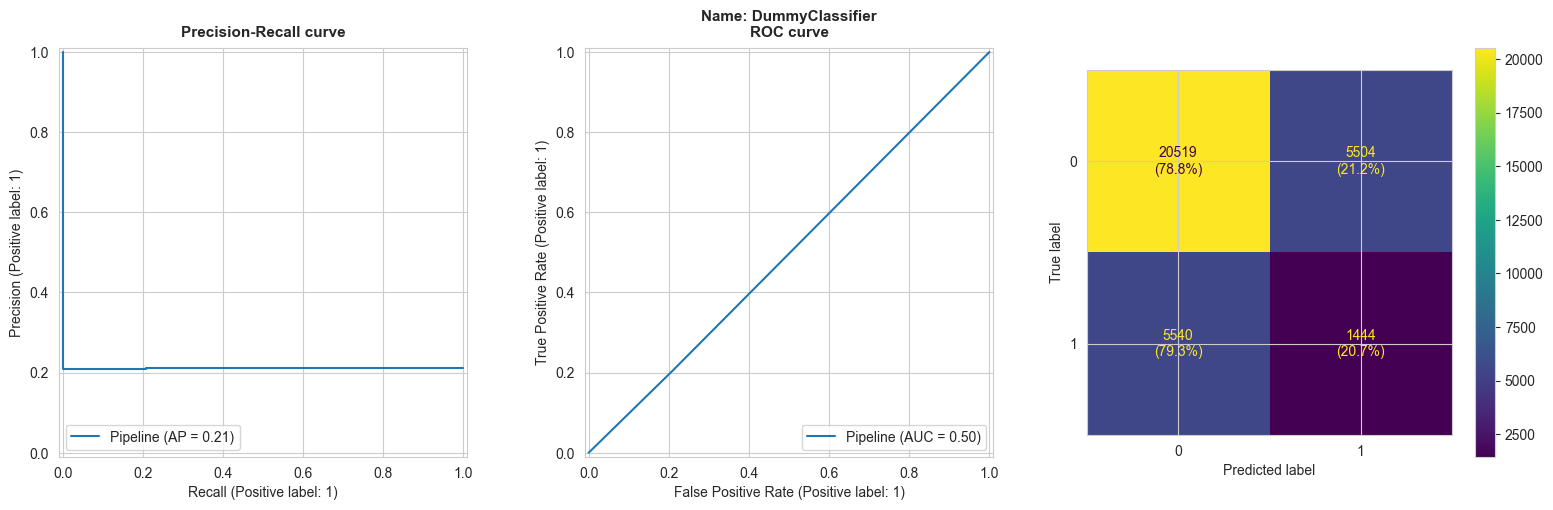

{'roc_auc': 0.4976,
 'accuracy': 0.6654,
 'recall': 0.2068,
 'precision': 0.2078,
 'f2_weighted': 0.6653,
 'lift_10pct': np.float64(0.9552),
 'fbps': np.float64(-19724335.9814),
 'train_time_s': 0.7}

In [6]:
pipeline_dummy = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)),
])
evaluate_model(pipeline_dummy, 'DummyClassifier')

<a id="section-6"></a>
# Section 6 : Gaussian Naive Bayes

Classifieur probabiliste basé sur le théorème de Bayes avec hypothèse d'**indépendance conditionnelle** et distribution gaussienne. Très rapide et interprétable.

`priors=[0.5, 0.5]` : a priori équilibrés — neutralise le biais de classe dans les probabilités a posteriori.

── GaussianNB  |  CV bench (30,000 obs.)  |  cv_time = 8.3 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
GaussianNB,0.8016,0.728,0.7169,0.417,0.7321,8.3


── GaussianNB  |  Jeu de test (seuil=0.45)  |  train_time = 0.7 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,fbps,train_time_s
GaussianNB,0.7957,0.7101,0.7448,0.4005,0.7137,3.0347,2.384586e+07,0.7


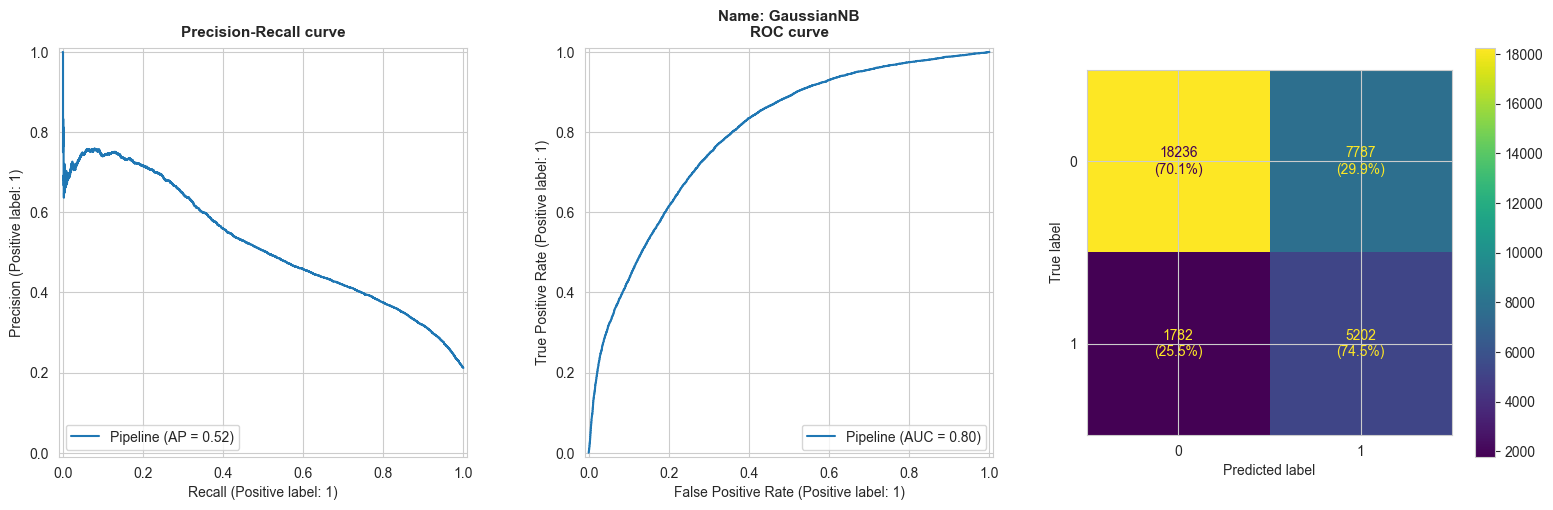

{'roc_auc': 0.7957,
 'accuracy': 0.7101,
 'recall': 0.7448,
 'precision': 0.4005,
 'f2_weighted': 0.7137,
 'lift_10pct': np.float64(3.0347),
 'fbps': np.float64(23845857.7716),
 'train_time_s': 0.7}

In [7]:
pipeline_gnb = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', GaussianNB(priors=[0.5, 0.5])),
])
evaluate_model(pipeline_gnb, 'GaussianNB')

<a id="section-7"></a>
# Section 7 : Logistic Regression

Modele lineaire classique entraine par **regression logistique** avec regularisation L2. Sert de reference lineaire face aux modeles ensemblistes.

── LogisticRegression  |  CV bench (30,000 obs.)  |  cv_time = 8.3 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
LogisticRegression,0.823,0.7529,0.7442,0.4493,0.7564,8.3


── LogisticRegression  |  Jeu de test (seuil=0.45)  |  train_time = 1.2 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,fbps,train_time_s
LogisticRegression,0.8193,0.7227,0.7871,0.4176,0.7254,3.3512,2.063849e+07,1.2


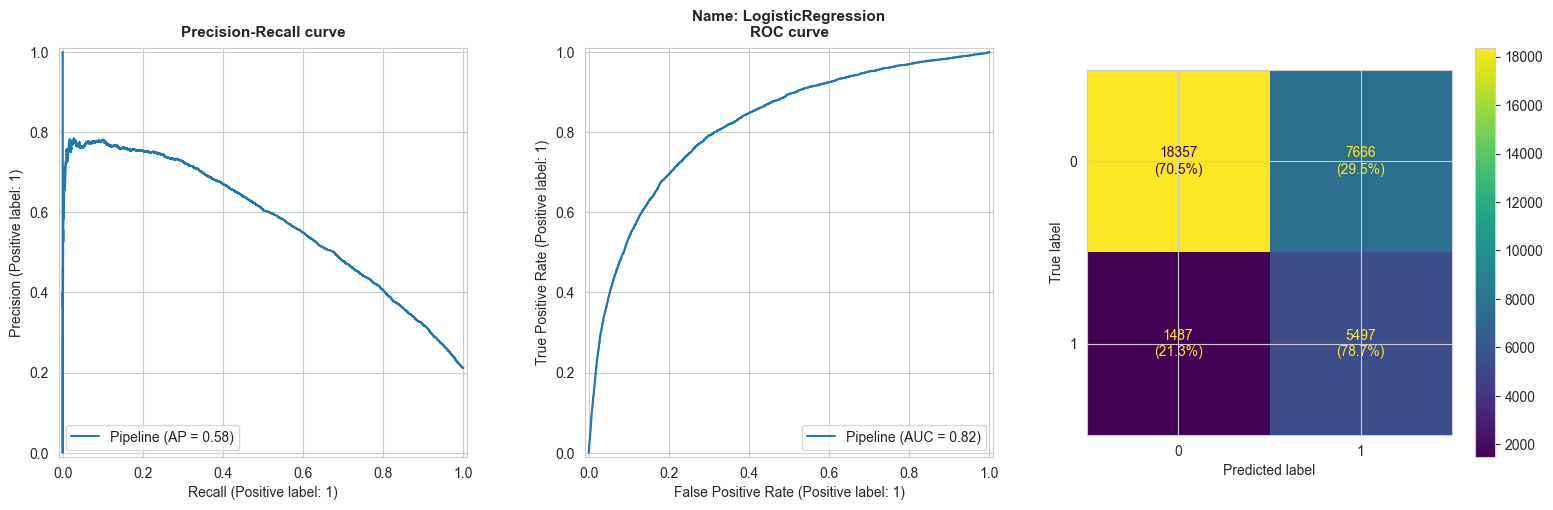

{'roc_auc': 0.8193,
 'accuracy': 0.7227,
 'recall': 0.7871,
 'precision': 0.4176,
 'f2_weighted': 0.7254,
 'lift_10pct': np.float64(3.3512),
 'fbps': np.float64(20638487.2698),
 'train_time_s': 1.2}

In [8]:
pipeline_lr = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )),
])
evaluate_model(pipeline_lr, 'LogisticRegression')

<a id="section-8"></a>
# Section 8 : Decision Tree

Arbre de décision unique entraîné par **partitionnement récursif** (critère Gini), limité à `max_depth=8`. Très interprétable mais sensible au surapprentissage.

`class_weight='balanced'` : poids d'entraînement inversement proportionnels à la fréquence de classe — les churners ont un poids ~3.73× plus élevé.

── DecisionTree  |  CV bench (30,000 obs.)  |  cv_time = 0.8 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
DecisionTree,0.8528,0.8025,0.7472,0.5233,0.8052,0.8


── DecisionTree  |  Jeu de test (seuil=0.45)  |  train_time = 2.1 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,fbps,train_time_s
DecisionTree,0.8824,0.7875,0.8183,0.4986,0.7897,3.9341,2.060094e+07,2.1


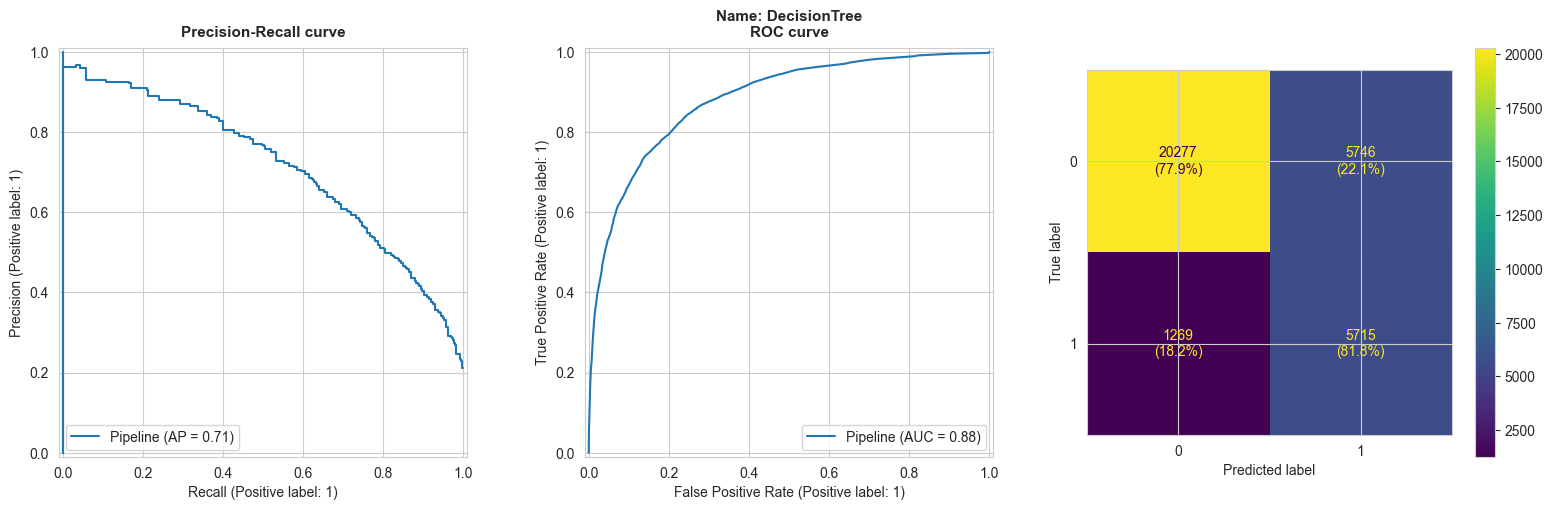

{'roc_auc': 0.8824,
 'accuracy': 0.7875,
 'recall': 0.8183,
 'precision': 0.4986,
 'f2_weighted': 0.7897,
 'lift_10pct': np.float64(3.9341),
 'fbps': np.float64(20600944.0854),
 'train_time_s': 2.1}

In [9]:
pipeline_dt = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', DecisionTreeClassifier(
        max_depth=8,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    )),
])
evaluate_model(pipeline_dt, 'DecisionTree')

<a id="section-9"></a>
# Section 9 : K-Nearest Neighbors

Prédiction par **vote parmi les k=15 plus proches voisins**. Méthode non paramétrique, sensible à l'échelle (standardisation).

`weights='distance'` : les voisins proches ont plus de poids que les voisins lointains — proxy de rééquilibrage pour KNN (pas de `class_weight` natif).

── KNN  |  CV bench (30,000 obs.)  |  cv_time = 8.2 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
KNN,0.855,0.8503,0.483,0.7173,0.8446,8.2


── KNN  |  Jeu de test (seuil=0.45)  |  train_time = 1.2 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,fbps,train_time_s
KNN,0.8603,0.8527,0.5533,0.6894,0.8498,3.7637,2.743310e+06,1.2


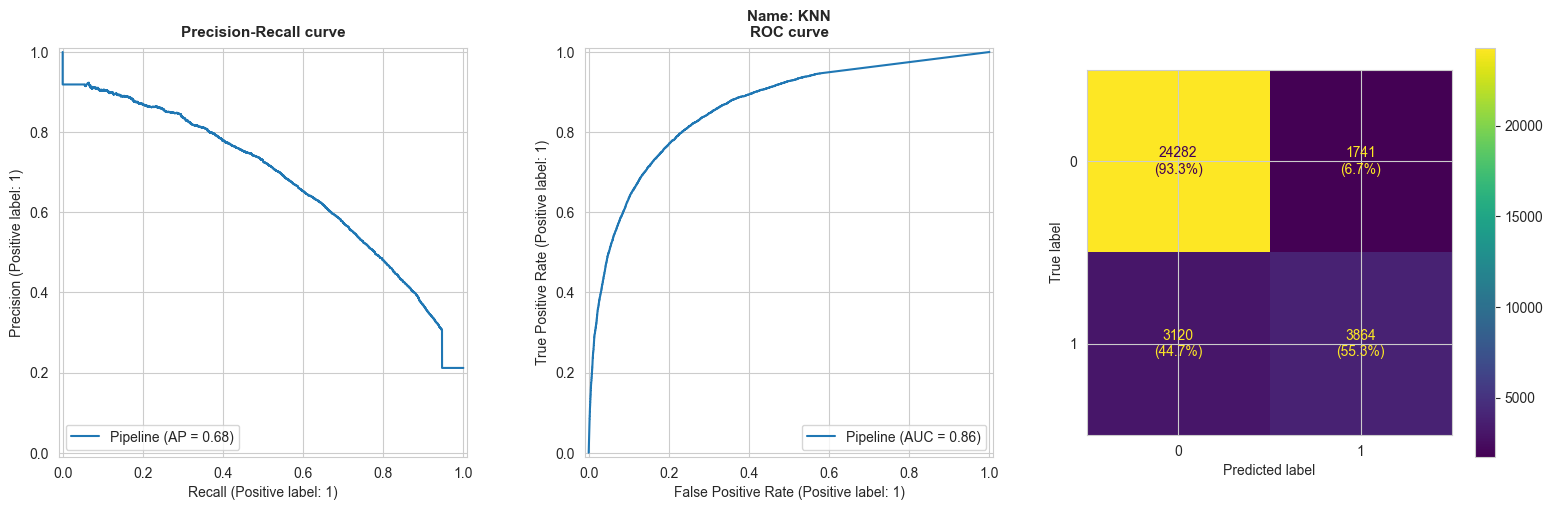

{'roc_auc': 0.8603,
 'accuracy': 0.8527,
 'recall': 0.5533,
 'precision': 0.6894,
 'f2_weighted': 0.8498,
 'lift_10pct': np.float64(3.7637),
 'fbps': np.float64(2743309.8276),
 'train_time_s': 1.2}

In [10]:
pipeline_knn = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', KNeighborsClassifier(n_neighbors=15, weights='distance')),
])
evaluate_model(pipeline_knn, 'KNN')

<a id="section-10"></a>
# Section 10 : AdaBoost

**Boosting adaptatif** : chaque itération augmente le poids des observations mal classées. Utilise des stumps (arbres à 1 nœud). Sensible au bruit.

`class_weight='balanced'` sur le classifieur de base : la correction se propage via le mécanisme de pondération AdaBoost.

── AdaBoost  |  CV bench (30,000 obs.)  |  cv_time = 0.6 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
AdaBoost,0.8414,0.8222,0.5629,0.595,0.8214,0.6


── AdaBoost  |  Jeu de test (seuil=0.45)  |  train_time = 1.8 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,fbps,train_time_s
AdaBoost,0.8473,0.8402,0.5467,0.6444,0.838,3.6649,3.473267e+06,1.8


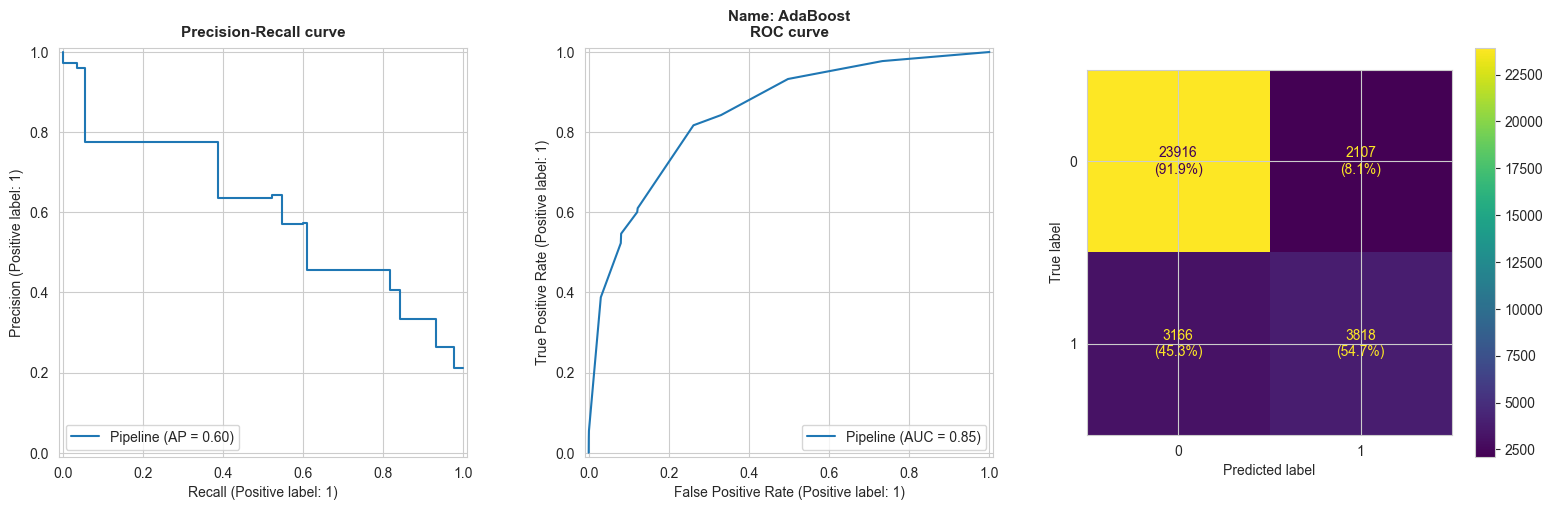

{'roc_auc': 0.8473,
 'accuracy': 0.8402,
 'recall': 0.5467,
 'precision': 0.6444,
 'f2_weighted': 0.838,
 'lift_10pct': np.float64(3.6649),
 'fbps': np.float64(3473266.7944),
 'train_time_s': 1.8}

In [11]:
base_dt = DecisionTreeClassifier(max_depth=1, class_weight='balanced', random_state=RANDOM_STATE)
pipeline_ada = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', AdaBoostClassifier(
        estimator=base_dt,
        n_estimators=100,
        learning_rate=0.5,
        random_state=RANDOM_STATE,
    )),
])
evaluate_model(pipeline_ada, 'AdaBoost')

<a id="section-11"></a>
# Section 11 : Random Forest

Ensemble d'arbres entraînés sur des **sous-échantillons bootstrap** avec sélection aléatoire de variables. Réduit la variance par agrégation (bagging). Robuste aux outliers.

`class_weight='balanced'` : poids inversement proportionnels à la fréquence — sur-représente les churners à chaque nœud.

── RandomForest  |  CV bench (30,000 obs.)  |  cv_time = 5.0 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
RandomForest,0.8719,0.8601,0.5077,0.7508,0.8547,5.0


── RandomForest  |  Jeu de test (seuil=0.45)  |  train_time = 14.7 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,fbps,train_time_s
RandomForest,0.8732,0.8561,0.561,0.6995,0.8533,3.8668,3.296841e+06,14.7


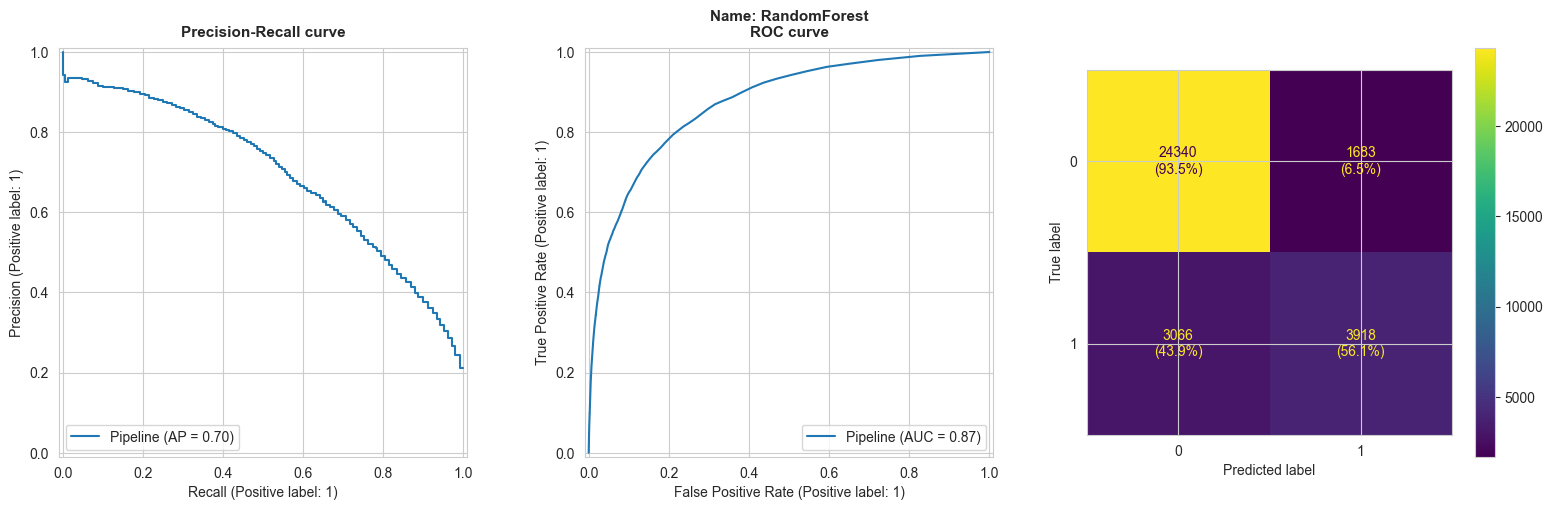

{'roc_auc': 0.8732,
 'accuracy': 0.8561,
 'recall': 0.561,
 'precision': 0.6995,
 'f2_weighted': 0.8533,
 'lift_10pct': np.float64(3.8668),
 'fbps': np.float64(3296841.3762),
 'train_time_s': 14.7}

In [12]:
pipeline_rf = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
evaluate_model(pipeline_rf, 'RandomForest')

<a id="section-12"></a>
# Section 12 : Extra Trees

Variante du Random Forest où les **seuils de coupure sont tirés aléatoirement**. Entraînement plus rapide, variance encore plus réduite.

`class_weight='balanced'` : poids inversement proportionnels à la fréquence de classe.

── ExtraTrees  |  CV bench (30,000 obs.)  |  cv_time = 3.9 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
ExtraTrees,0.8666,0.8555,0.5197,0.72,0.851,3.9


── ExtraTrees  |  Jeu de test (seuil=0.45)  |  train_time = 8.8 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,fbps,train_time_s
ExtraTrees,0.8651,0.8512,0.5713,0.6756,0.8491,3.8009,4223788.701,8.8


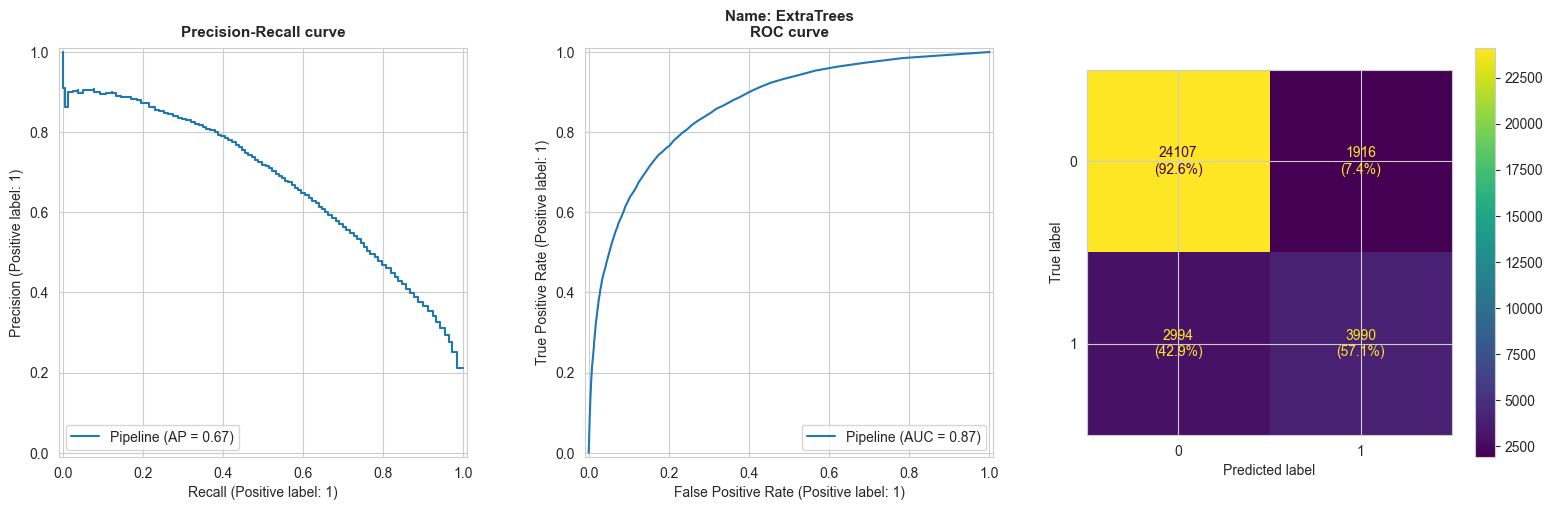

{'roc_auc': 0.8651,
 'accuracy': 0.8512,
 'recall': 0.5713,
 'precision': 0.6756,
 'f2_weighted': 0.8491,
 'lift_10pct': np.float64(3.8009),
 'fbps': np.float64(4223788.701),
 'train_time_s': 8.8}

In [13]:
pipeline_et = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', ExtraTreesClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
evaluate_model(pipeline_et, 'ExtraTrees')

<a id="section-13"></a>
# Section 13 : Gradient Boosting

**Construction séquentielle** d'arbres : chaque arbre corrige les erreurs résiduelles du précédent par descente de gradient sur la log-loss.

`subsample=0.8` : sous-échantillonnage stochastique à chaque étape — proxy du rééquilibrage (`class_weight` non supporté nativement dans sklearn).

> ⚠️ GradientBoosting est séquentiel, la CV est lancée avec `cv_njobs=1` pour éviter la surcharge mémoire.

── GradientBoosting  |  CV bench (30,000 obs.)  |  cv_time = 37.7 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
GradientBoosting,0.8871,0.8654,0.5498,0.7477,0.8614,37.7


── GradientBoosting  |  Jeu de test (seuil=0.45)  |  train_time = 99.6 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,fbps,train_time_s
GradientBoosting,0.8894,0.8656,0.5869,0.7255,0.863,3.9585,5168868.517,99.6


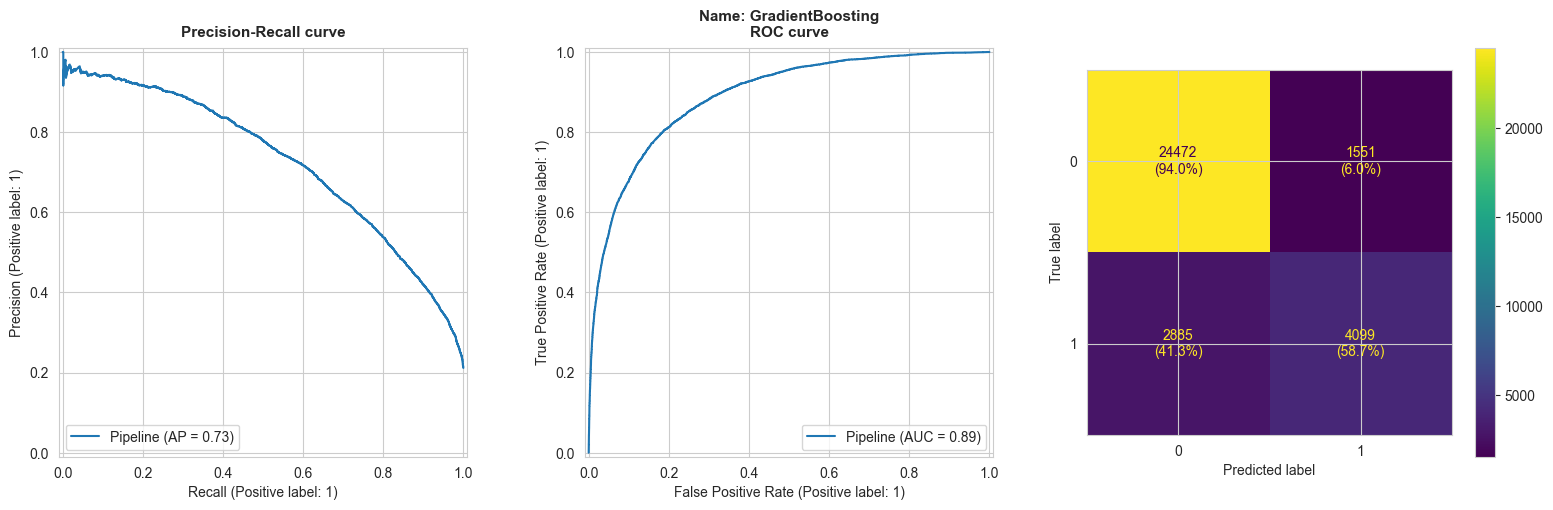

{'roc_auc': 0.8894,
 'accuracy': 0.8656,
 'recall': 0.5869,
 'precision': 0.7255,
 'f2_weighted': 0.863,
 'lift_10pct': np.float64(3.9585),
 'fbps': np.float64(5168868.517),
 'train_time_s': 99.6}

In [14]:
pipeline_gb = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        subsample=0.8,
        random_state=RANDOM_STATE,
    )),
])
evaluate_model(pipeline_gb, 'GradientBoosting', cv_njobs=1)

<a id="section-14"></a>
# Section 14 : XGBoost

Gradient boosting optimisé avec **régularisation L1/L2**, élagage des arbres et parallélisation. Généralement l'un des meilleurs algorithmes sur données tabulaires.

`scale_pos_weight = n_négatifs / n_positifs ≈ 3.73` : augmente le gradient des churners, leur donnant plus d'importance lors de l'optimisation.

── XGBoost  |  CV bench (30,000 obs.)  |  cv_time = 5.0 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
XGBoost,0.8623,0.8334,0.6882,0.5913,0.8348,5.0


── XGBoost  |  Jeu de test (seuil=0.45)  |  train_time = 3.5 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,fbps,train_time_s
XGBoost,0.882,0.8042,0.7915,0.5247,0.8066,3.9212,1.826805e+07,3.5


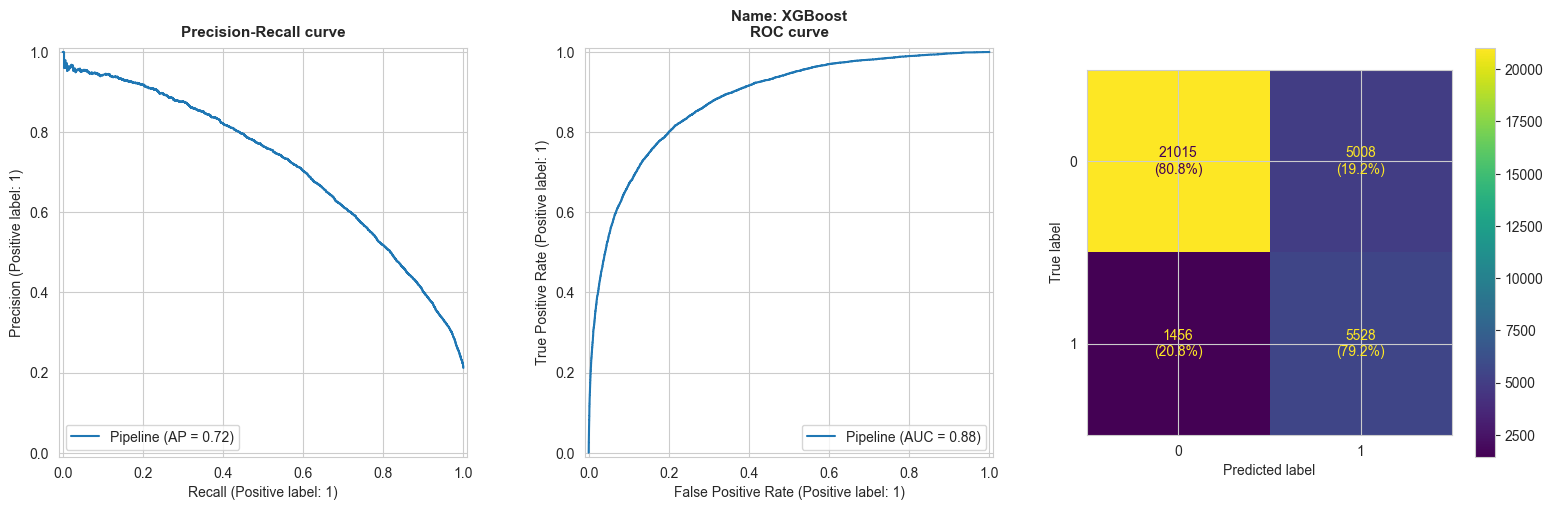

In [15]:
if HAS_XGB:
    pipeline_xgb = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('model', XGBClassifier(
            n_estimators=150,
            scale_pos_weight=SCALE_POS_WEIGHT,
            eval_metric='logloss',
            random_state=RANDOM_STATE,
            verbosity=0,
            n_jobs=-1,
        )),
    ])
    evaluate_model(pipeline_xgb, 'XGBoost', cv_njobs=1)
else:
    print('XGBoost non disponible — pip install xgboost')

<a id="section-15"></a>
# Section 15 : LightGBM

Gradient boosting basé sur des **histogrammes de features**. Très rapide sur les grands datasets grâce à la croissance feuille par feuille.

`is_unbalance=True` : ajustement automatique des poids de classe par LightGBM — équivalent à `class_weight='balanced'` dans sklearn.

── LightGBM  |  CV bench (30,000 obs.)  |  cv_time = 7.8 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
LightGBM,0.8815,0.8219,0.7494,0.559,0.8241,7.8


── LightGBM  |  Jeu de test (seuil=0.45)  |  train_time = 5.6 s ──


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,fbps,train_time_s
LightGBM,0.8895,0.7957,0.8213,0.5107,0.7978,3.9499,2.066346e+07,5.6


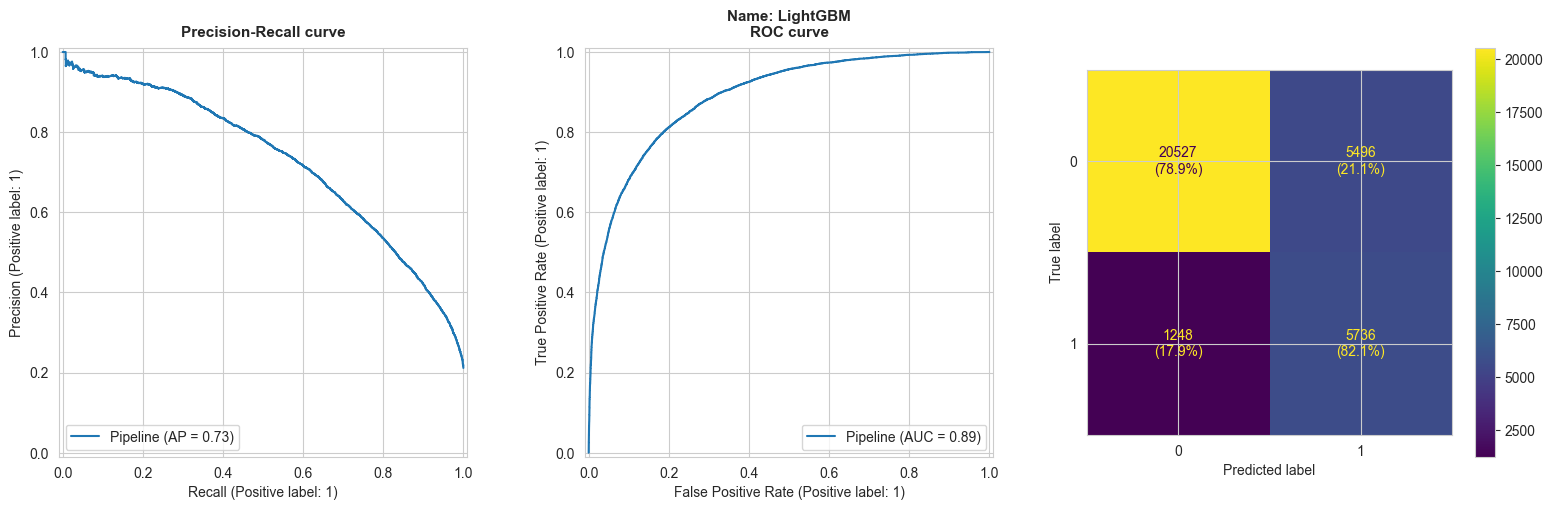

In [16]:
if HAS_LGBM:
    pipeline_lgbm = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('model', LGBMClassifier(
            n_estimators=150,
            is_unbalance=True,
            random_state=RANDOM_STATE,
            verbose=-1,
            n_jobs=-1,
        )),
    ])
    evaluate_model(pipeline_lgbm, 'LightGBM', cv_njobs=1)
else:
    print('LightGBM non disponible — pip install lightgbm')

<a id="section-16"></a>
# Section 16 : Comparaison des modèles

Critère de sélection : **F2-weighted** en priorité (favorise le rappel des churners, pondéré par le déséquilibre de classes), puis **Lift@10 %** pour l'utilité opérationnelle.

In [17]:
df_cv = (
    pd.DataFrame(cv_results)
    .T
    .rename_axis('modele')
    .sort_values('f2_weighted', ascending=False)
)
print('Résultats — Validation croisée (benchmark, 30 000 obs.) :')
display(df_cv)

Résultats — Validation croisée (benchmark, 30 000 obs.) :


,roc_auc,accuracy,recall,precision,f2_weighted,cv_time_s
modele,,,,,,
GradientBoosting,0.8871,0.8654,0.5498,0.7477,0.8614,37.7
RandomForest,0.8719,0.8601,0.5077,0.7508,0.8547,5.0
ExtraTrees,0.8666,0.8555,0.5197,0.7200,0.8510,3.9
KNN,0.8550,0.8503,0.4830,0.7173,0.8446,8.2
XGBoost,0.8623,0.8334,0.6882,0.5913,0.8348,5.0
LightGBM,0.8815,0.8219,0.7494,0.5590,0.8241,7.8
AdaBoost,0.8414,0.8222,0.5629,0.5950,0.8214,0.6
DecisionTree,0.8528,0.8025,0.7472,0.5233,0.8052,0.8
LogisticRegression,0.8230,0.7529,0.7442,0.4493,0.7564,8.3


In [18]:
df_test = (
    pd.DataFrame(test_results)
    .T
    .rename_axis('modele')
    .sort_values('f2_weighted', ascending=False)
)
print('Résultats — Jeu de test :')
display(df_test)

Résultats — Jeu de test :


,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,fbps,train_time_s
modele,,,,,,,,
GradientBoosting,0.8894,0.8656,0.5869,0.7255,0.8630,3.9585,5.168869e+06,99.6
RandomForest,0.8732,0.8561,0.5610,0.6995,0.8533,3.8668,3.296841e+06,14.7
KNN,0.8603,0.8527,0.5533,0.6894,0.8498,3.7637,2.743310e+06,1.2
ExtraTrees,0.8651,0.8512,0.5713,0.6756,0.8491,3.8009,4.223789e+06,8.8
AdaBoost,0.8473,0.8402,0.5467,0.6444,0.8380,3.6649,3.473267e+06,1.8
XGBoost,0.8820,0.8042,0.7915,0.5247,0.8066,3.9212,1.826805e+07,3.5
LightGBM,0.8895,0.7957,0.8213,0.5107,0.7978,3.9499,2.066346e+07,5.6
DecisionTree,0.8824,0.7875,0.8183,0.4986,0.7897,3.9341,2.060094e+07,2.1
LogisticRegression,0.8193,0.7227,0.7871,0.4176,0.7254,3.3512,2.063849e+07,1.2


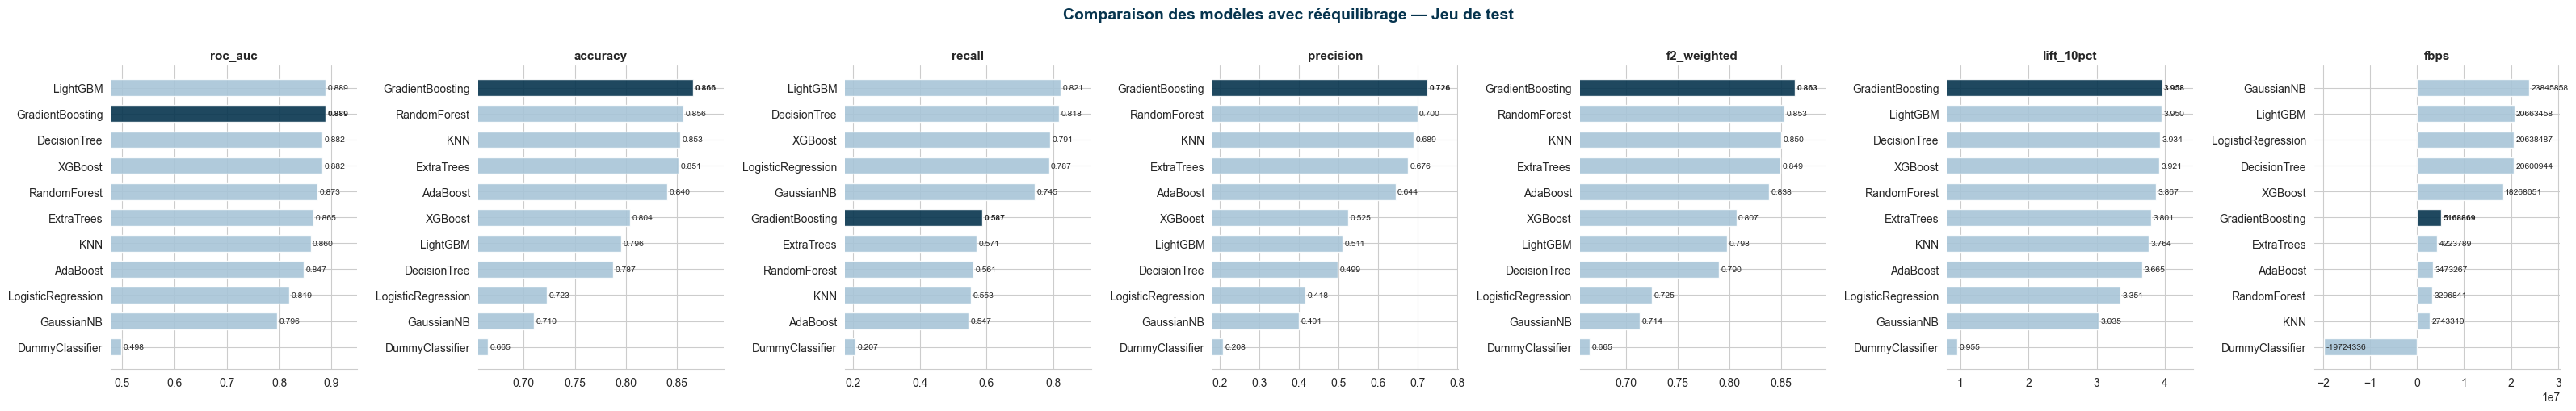

Meilleur modèle (F2-weighted) : GradientBoosting


In [19]:
metrics_to_plot = ['roc_auc', 'accuracy', 'recall', 'precision', 'f2_weighted', 'lift_10pct', 'fbps']
best_model_name = df_test['f2_weighted'].idxmax()

fig, axes = plt.subplots(1, 7, figsize=(32, 5))
fig.patch.set_facecolor("white")

for ax, metric in zip(axes, metrics_to_plot):
    col_data = df_test[metric].dropna().sort_values()
    colors = ["#06344e" if m == best_model_name else "#a8c5d8" for m in col_data.index]
    ax.barh(col_data.index, col_data.values, color=colors, alpha=0.9,
            edgecolor="white", height=0.65)
    ax.set_title(metric, fontweight="bold", fontsize=11, pad=6)
    span = max(abs(col_data.max() - col_data.min()), 1e-3)
    xlim_lo = col_data.min() - 0.05 * span
    xlim_hi = col_data.max() + 0.15 * span
    ax.set_xlim(xlim_lo, xlim_hi)
    offset = 0.01 * span
    fmt = ".0f" if metric == "fbps" else ".3f"
    for i, (m, v) in enumerate(zip(col_data.index, col_data.values)):
        fw = "bold" if m == best_model_name else "normal"
        ax.text(v + offset, i, f"{v:{fmt}}", va="center", fontsize=7.5, fontweight=fw)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", left=False)

fig.suptitle('Comparaison des modèles avec rééquilibrage — Jeu de test',
             fontsize=14, fontweight='bold', color='#06344e', y=1.01)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'benchmark_metrics1.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Meilleur modèle (F2-weighted) : {best_model_name}')

<a id="section-17"></a>
# Section 17 : Tuning du meilleur modele

Optimisation des hyperparametres par **Optuna** (*Tree-structured Parzen Estimator* - TPE) sur X_train complet :

| Parametre | Valeur | Justification |
|---|---|---|
| **Algorithme** | TPE | Modelise la distribution des bons parametres, plus efficace que la recherche aleatoire a budget egal. |
| **Essais** | 50 | Chaque essai evalue le pipeline sur 3 folds -> 150 fits au total. |
| **Scorer** | F2-weighted | Coherent avec le critere de selection du benchmark. |
| **Reentrainement** | X_train complet | Apres optimisation sur X_bench, le meilleur pipeline est reentraine sur toutes les donnees d'entrainement. |

In [20]:
N_TRIALS = 50
N_FOLDS  = 3

_NO_TUNE = {'DummyClassifier'}


def _suggest_params(trial, model_name):
    if model_name == 'LightGBM':
        return {
            'model__n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
            'model__learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.35, log=True),
            'model__num_leaves'       : trial.suggest_int('num_leaves', 15, 150),
            'model__min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
            'model__subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
            'model__colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'model__reg_alpha'        : trial.suggest_float('reg_alpha', 0.0, 2.0),
            'model__reg_lambda'       : trial.suggest_float('reg_lambda', 0.0, 2.0),
        }
    if model_name == 'XGBoost':
        return {
            'model__n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
            'model__learning_rate'   : trial.suggest_float('learning_rate', 0.005, 0.35, log=True),
            'model__max_depth'       : trial.suggest_int('max_depth', 2, 10),
            'model__subsample'       : trial.suggest_float('subsample', 0.5, 1.0),
            'model__colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
            'model__reg_alpha'       : trial.suggest_float('reg_alpha', 0.0, 3.0),
            'model__reg_lambda'      : trial.suggest_float('reg_lambda', 0.0, 3.0),
            'model__min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        }
    if model_name == 'GradientBoosting':
        return {
            'model__n_estimators'     : trial.suggest_int('n_estimators', 50, 300),
            'model__learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'model__max_depth'        : trial.suggest_int('max_depth', 2, 8),
            'model__subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
            'model__min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'model__min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        }
    if model_name == 'RandomForest':
        return {
            'model__n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
            'model__max_depth'        : trial.suggest_categorical('max_depth', [None, 5, 10, 15, 20, 25]),
            'model__min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
            'model__min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 15),
            'model__max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, 0.7]),
        }
    if model_name == 'ExtraTrees':
        return {
            'model__n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
            'model__max_depth'        : trial.suggest_categorical('max_depth', [None, 5, 10, 15, 20]),
            'model__min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
            'model__min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 15),
        }
    if model_name == 'DecisionTree':
        return {
            'model__max_depth'        : trial.suggest_int('max_depth', 2, 20),
            'model__min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
            'model__min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 20),
            'model__max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        }
    if model_name == 'KNN':
        return {
            'model__n_neighbors': trial.suggest_int('n_neighbors', 3, 50),
            'model__weights'    : trial.suggest_categorical('weights', ['uniform', 'distance']),
            'model__metric'     : trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski']),
        }
    if model_name == 'AdaBoost':
        return {
            'model__n_estimators' : trial.suggest_int('n_estimators', 50, 300),
            'model__learning_rate': trial.suggest_float('learning_rate', 0.005, 1.5),
        }
    if model_name == 'GaussianNB':
        return {
            'model__var_smoothing': trial.suggest_float('var_smoothing', 1e-11, 1e-5, log=True),
        }
    if model_name == 'LogisticRegression':
        return {
            'model__C': trial.suggest_float('C', 1e-3, 100, log=True),
        }
    return {}


def objective(trial):
    params = _suggest_params(trial, best_model_name)
    p = clone(trained_models[best_model_name])
    p.set_params(**params)
    cv_optuna = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(
        p, X_bench, y_bench,
        cv=cv_optuna, scoring=f2_weighted_scorer, n_jobs=-1,
    )
    return float(np.mean(scores['test_score']))


if not HAS_OPTUNA or best_model_name in _NO_TUNE:
    reason = 'Optuna non disponible' if not HAS_OPTUNA else f'pas de paramètres à optimiser pour {best_model_name}'
    print(f'Tuning ignoré : {reason}.')
    tuned_pipeline = trained_models[best_model_name]
    tuning_results = None
    best_cv_score  = None
else:
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

    tuning_results = pd.DataFrame([
        {'trial': t.number, 'mean_test_score': t.value, **t.params}
        for t in study.trials if t.value is not None
    ])
    best_cv_score = study.best_value

    best_params_optuna = {f'model__{k}': v for k, v in study.best_params.items()}
    tuned_pipeline = clone(trained_models[best_model_name])
    tuned_pipeline.set_params(**best_params_optuna)
    tuned_pipeline.fit(X_train, y_train)

    print(f'\nMeilleur F2-weighted CV (bench) : {best_cv_score:.4f}')
    print('Meilleurs paramètres :')
    for k, v in study.best_params.items():
        print(f'  {k}: {v}')

Best trial: 21. Best value: 0.861851: 100%|██████████| 50/50 [54:34<00:00, 65.49s/it]   



Meilleur F2-weighted CV (bench) : 0.8619
Meilleurs paramètres :
  n_estimators: 273
  learning_rate: 0.04627136691511048
  max_depth: 4
  subsample: 0.5351239441373358
  min_samples_split: 15
  min_samples_leaf: 7


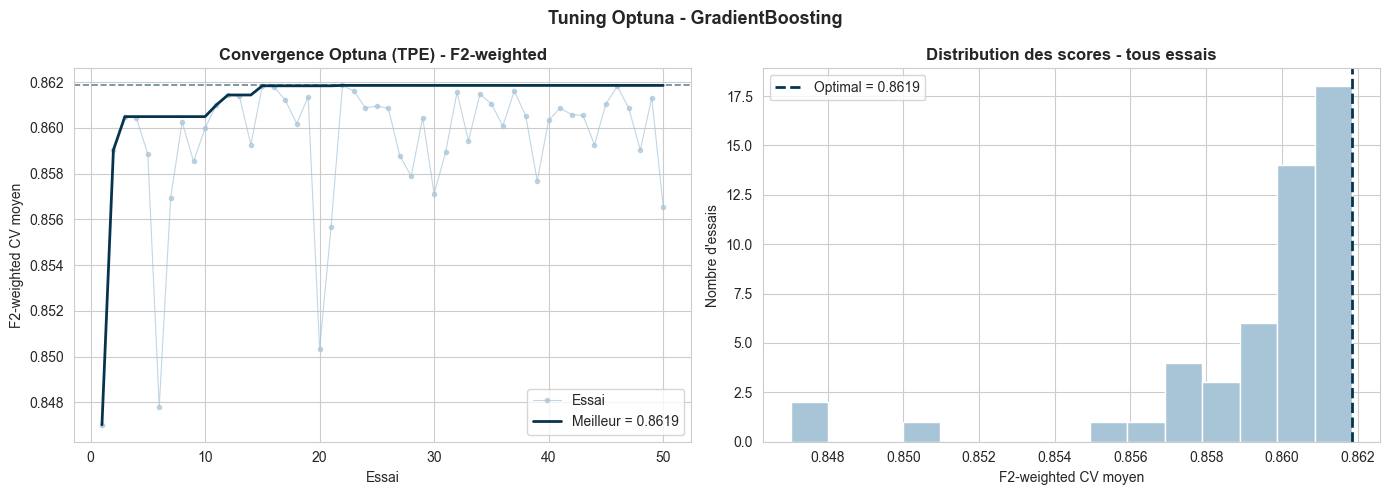

In [21]:
if tuning_results is not None:
    cummax = np.maximum.accumulate(tuning_results['mean_test_score'].fillna(-np.inf))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(
        tuning_results['trial'] + 1,
        tuning_results['mean_test_score'],
        marker='o', ms=3, linewidth=0.8, color='#a8c5d8', alpha=0.7, label='Essai',
    )
    axes[0].plot(
        tuning_results['trial'] + 1,
        cummax,
        color='#06344e', linewidth=2, label=f'Meilleur = {best_cv_score:.4f}',
    )
    axes[0].axhline(best_cv_score, color='#06344e', linestyle='--', linewidth=1.2, alpha=0.6)
    axes[0].set_title('Convergence Optuna (TPE) - F2-weighted', fontweight='bold')
    axes[0].set_xlabel('Essai')
    axes[0].set_ylabel('F2-weighted CV moyen')
    axes[0].legend()

    axes[1].hist(tuning_results['mean_test_score'].dropna(), bins=15,
                 color='#a8c5d8', edgecolor='white')
    axes[1].axvline(best_cv_score, color='#06344e', linestyle='--', linewidth=2,
                    label=f'Optimal = {best_cv_score:.4f}')
    axes[1].set_title('Distribution des scores - tous essais', fontweight='bold')
    axes[1].set_xlabel('F2-weighted CV moyen')
    axes[1].set_ylabel("Nombre d'essais")
    axes[1].legend()

    plt.suptitle(f'Tuning Optuna - {best_model_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'tuning_history.png', dpi=300, bbox_inches='tight')
    plt.show()

<a id="section-18"></a>
# Section 18 : Évaluation finale

Comparaison avant / après tuning sur le jeu de test, puis analyse détaillée du modèle retenu.

In [22]:
rows = [
    {'modele': 'Avant tuning', **compute_test_metrics(trained_models[best_model_name], X_test, y_test)},
]
if tuning_results is not None:
    rows.append({'modele': 'Après tuning', **compute_test_metrics(tuned_pipeline, X_test, y_test)})

final_metrics_df = pd.DataFrame(rows).set_index('modele')
display(final_metrics_df)

eval_pipeline = tuned_pipeline if tuning_results is not None else trained_models[best_model_name]
y_score = eval_pipeline.predict_proba(X_test)[:, 1]
y_pred  = (y_score >= BEST_THRESHOLD).astype(int)

print(f'\nRapport de classification — {best_model_name} (seuil = {BEST_THRESHOLD}) :')
print(classification_report(y_test, y_pred, target_names=['Non-churn', 'Churn'], digits=4))

,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,fbps
modele,,,,,,,
Avant tuning,0.8894,0.8656,0.5869,0.7255,0.8630,3.9585,5.168869e+06
Après tuning,0.8899,0.8660,0.5896,0.7258,0.8635,3.9756,5.276092e+06



Rapport de classification — GradientBoosting (seuil = 0.45) :
              precision    recall  f1-score   support

   Non-churn     0.8951    0.9402    0.9171     26023
       Churn     0.7258    0.5896    0.6507      6984

    accuracy                         0.8660     33007
   macro avg     0.8105    0.7649    0.7839     33007
weighted avg     0.8593    0.8660    0.8607     33007



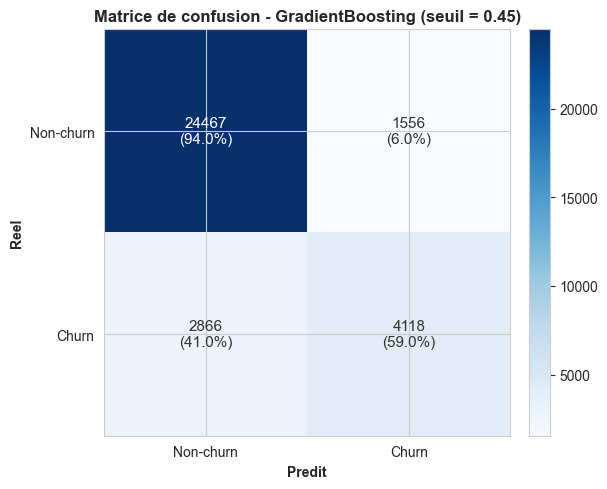

In [23]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
labels = ['Non-churn', 'Churn']
for r in range(2):
    for c in range(2):
        pct = cm[r, c] / cm[r].sum() * 100
        txt = f'{cm[r, c]}' + chr(10) + f'({pct:.1f}%)'
        ax.text(c, r, txt,
                ha='center', va='center', fontsize=11,
                color='white' if cm[r, c] > cm.max() / 2 else '#333333')
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel('Predit', fontweight='bold')
ax.set_ylabel('Reel', fontweight='bold')
ax.set_title(f'Matrice de confusion - {best_model_name} (seuil = {BEST_THRESHOLD})', fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

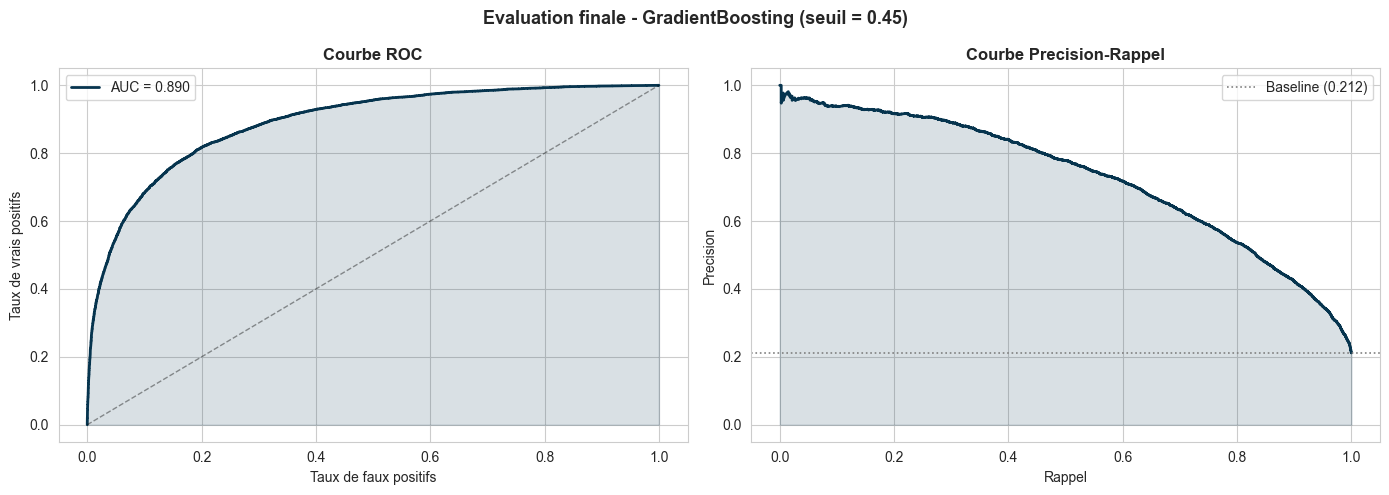

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test, y_score)
auc_val = roc_auc_score(y_test, y_score)
axes[0].plot(fpr, tpr, color='#06344e', linewidth=2, label=f'AUC = {auc_val:.3f}')
axes[0].fill_between(fpr, tpr, alpha=0.15, color='#06344e')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, linewidth=1)
axes[0].set_title('Courbe ROC', fontweight='bold')
axes[0].set_xlabel('Taux de faux positifs')
axes[0].set_ylabel('Taux de vrais positifs')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, y_score)
axes[1].plot(rec, prec, color='#06344e', linewidth=2)
axes[1].fill_between(rec, prec, alpha=0.15, color='#06344e')
axes[1].axhline(y_test.mean(), color='grey', linestyle=':', linewidth=1.2, label=f'Baseline ({y_test.mean():.3f})')
axes[1].set_title('Courbe Precision-Rappel', fontweight='bold')
axes[1].set_xlabel('Rappel')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.suptitle(f'Evaluation finale - {best_model_name} (seuil = {BEST_THRESHOLD})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

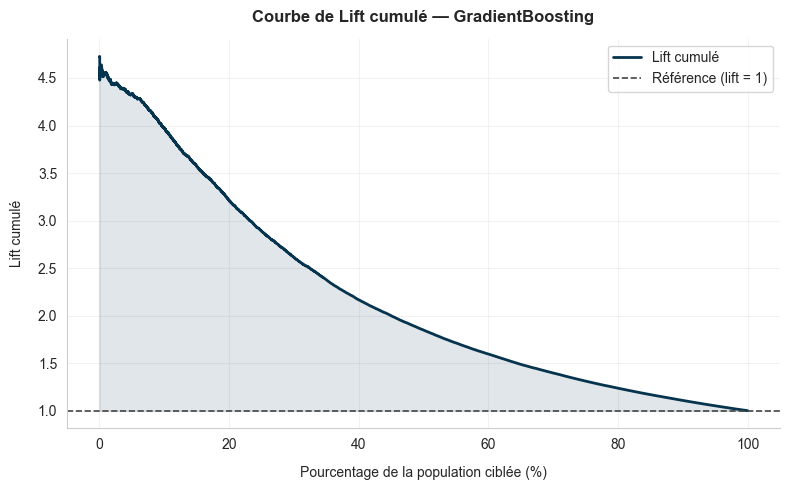

Lift@10% : 3.98x
Lift@20% : 3.21x
Lift@30% : 2.61x


In [25]:
# Courbe de lift cumulé
y_true_lift = y_test.reset_index(drop=True)

df_lift = pd.DataFrame({"y_true": y_true_lift, "y_proba": y_score})
df_lift = df_lift.sort_values("y_proba", ascending=False).reset_index(drop=True)

rate_pos           = df_lift["y_true"].mean()
df_lift["cum_pos"] = df_lift["y_true"].cumsum()
df_lift["n"]       = np.arange(1, len(df_lift) + 1)
df_lift["lift"]    = (df_lift["cum_pos"] / df_lift["n"]) / rate_pos
df_lift["pct_pop"] = df_lift["n"] / len(df_lift) * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_lift["pct_pop"], df_lift["lift"],
        color="#06344e", lw=2, label="Lift cumulé")
ax.fill_between(df_lift["pct_pop"], df_lift["lift"], 1,
                where=(df_lift["lift"] >= 1),
                alpha=0.12, color="#06344e")
ax.axhline(y=1, color="#444", linestyle="--", lw=1.2, label="Référence (lift = 1)")
ax.set_xlabel("Pourcentage de la population ciblée (%)", labelpad=10)
ax.set_ylabel("Lift cumulé", labelpad=10)
ax.set_title("Courbe de Lift cumulé — " + best_model_name, fontweight="bold", pad=12)
ax.legend(loc="upper right")
ax.grid(alpha=0.25)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "lift_curve.png", dpi=300, bbox_inches="tight")
plt.show()

for pct in [10, 20, 30]:
    n        = max(1, int(len(df_lift) * pct / 100))
    lift_val = df_lift.loc[n - 1, "lift"]
    print("Lift@" + str(pct) + "% : " + str(round(lift_val, 2)) + "x")

,feature,importance
1,Age,0.395903
4,NumOfProducts,0.320627
6,IsActiveMember,0.112871
8,Geography_Germany,0.051516
11,Balance_per_Product,0.028185
10,Gender_Male,0.027280
3,Balance,0.021377
13,Balance_Age_Ratio,0.014634
0,CreditScore,0.008021
7,EstimatedSalary,0.007335


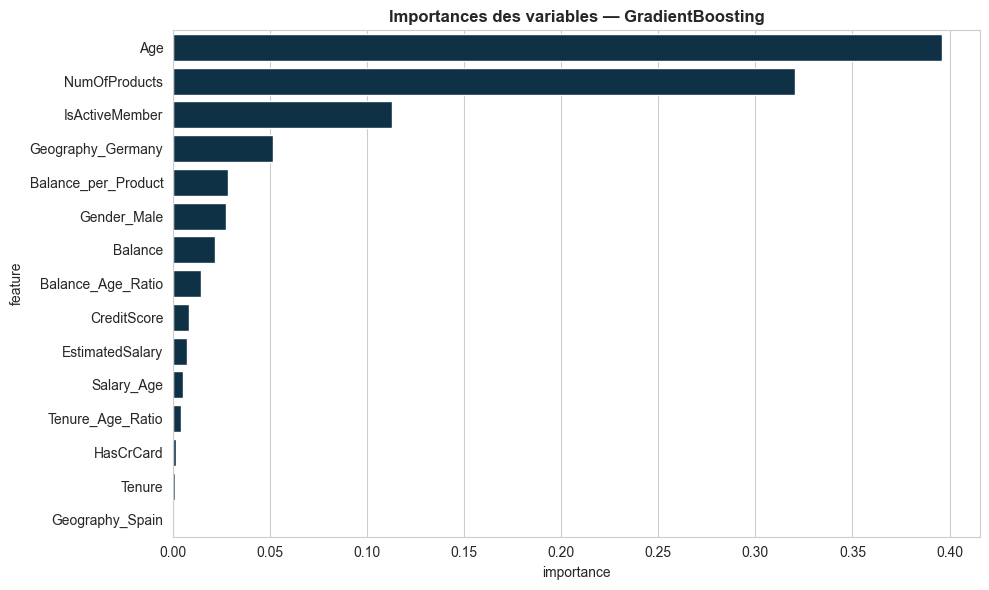

In [26]:
model_step = eval_pipeline.named_steps['model']

if hasattr(model_step, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature'   : X_train.columns,
        'importance': model_step.feature_importances_,
    }).sort_values('importance', ascending=False)
    display(importance_df.head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df.head(15), x='importance', y='feature', color='#06344e')
    plt.title(f'Importances des variables — {best_model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Le modele retenu ne fournit pas d'importance de variables directement.")


<a id="section-19"></a>
# Section 19 : Synthèse

## Récapitulatif des choix

**Métriques** : F2-weighted retenu comme critère principal car il combine rappel (× 2) et précision tout en tenant compte du déséquilibre des classes. Le Lift@10 % valide l'utilité opérationnelle pour les campagnes de rétention ciblées.

**Rééquilibrage** : traité au niveau de chaque algorithme (`class_weight`, `scale_pos_weight`, `is_unbalance`) plutôt que par sur-échantillonnage des données, pour éviter toute fuite d'information lors de la validation croisée. Comparer avec le notebook 03a (sans rééquilibrage) pour mesurer l'apport de ces mécanismes.

## Résultats finaux

In [27]:
print(f'Meilleur modèle : {best_model_name}')
print()
display(final_metrics_df)

Meilleur modèle : GradientBoosting



,roc_auc,accuracy,recall,precision,f2_weighted,lift_10pct,fbps
modele,,,,,,,
Avant tuning,0.8894,0.8656,0.5869,0.7255,0.8630,3.9585,5.168869e+06
Après tuning,0.8899,0.8660,0.5896,0.7258,0.8635,3.9756,5.276092e+06


<a id="section-20"></a>
# Section 20 : Explicabilité locale — SHAP (GradientBoosting)

L'explicabilité locale permet de comprendre **pourquoi** le modèle prédit un churn fort, moyen ou faible pour un individu donné.

| Outil | Rôle |
|---|---|
| **TreeExplainer** | Calcule les valeurs SHAP exactes pour les modèles à base d'arbres (GradientBoosting, XGBoost, LightGBM). |
| **Force plot** | Montre, pour un individu, quelles variables **poussent vers le churn** (rouge) ou **contre le churn** (bleu). |
| **Beeswarm plot** | Vue globale : distribution des valeurs SHAP sur tout le jeu de test — importance + direction d'effet. |

Trois profils représentatifs sont analysés :
- 🔴 **Risque élevé** : probabilité de churn maximale
- 🟡 **Risque moyen** : probabilité proche de 0.5 (cas ambigu)
- 🟢 **Risque faible** : probabilité de churn minimale

In [28]:
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print('SHAP non disponible. Installez-le avec : pip install shap')

if HAS_SHAP:
    # Pipeline GradientBoosting : tuné si c'est le meilleur modele, sinon base
    if best_model_name == 'GradientBoosting' and tuning_results is not None:
        gb_pipeline = tuned_pipeline
    else:
        gb_pipeline = trained_models['GradientBoosting']

    preprocessor_step  = gb_pipeline.named_steps['preprocessor']
    gb_model           = gb_pipeline.named_steps['model']

    X_test_arr         = preprocessor_step.transform(X_test)
    X_test_transformed = pd.DataFrame(X_test_arr, columns=X_test.columns)

    explainer   = shap.TreeExplainer(gb_model)
    shap_values = explainer(X_test_transformed)

    print('TreeExplainer initialise.')
    print('SHAP values shape : ' + str(shap_values.values.shape))

TreeExplainer initialise.
SHAP values shape : (33007, 15)


Risque eleve — Index 9287 — Proba churn : 0.978


<Figure size 1200x400 with 0 Axes>

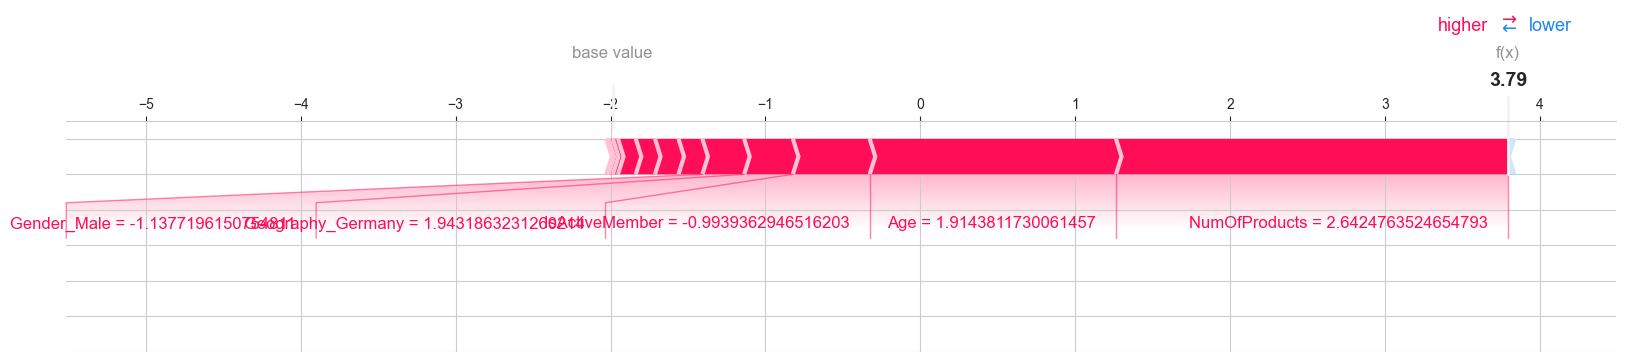

Risque moyen — Index 29396 — Proba churn : 0.5


<Figure size 1200x400 with 0 Axes>

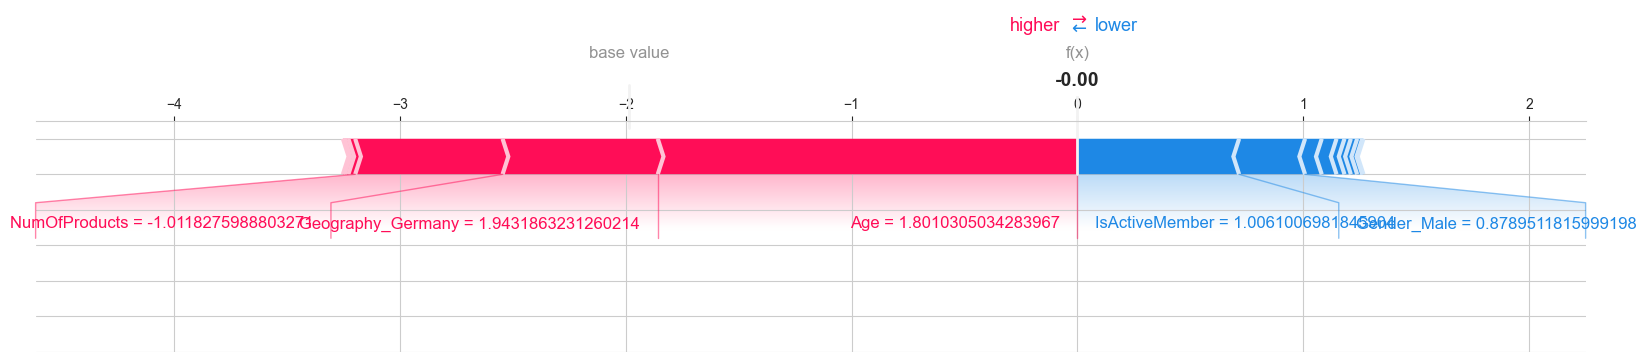

Risque faible — Index 4350 — Proba churn : 0.009


<Figure size 1200x400 with 0 Axes>

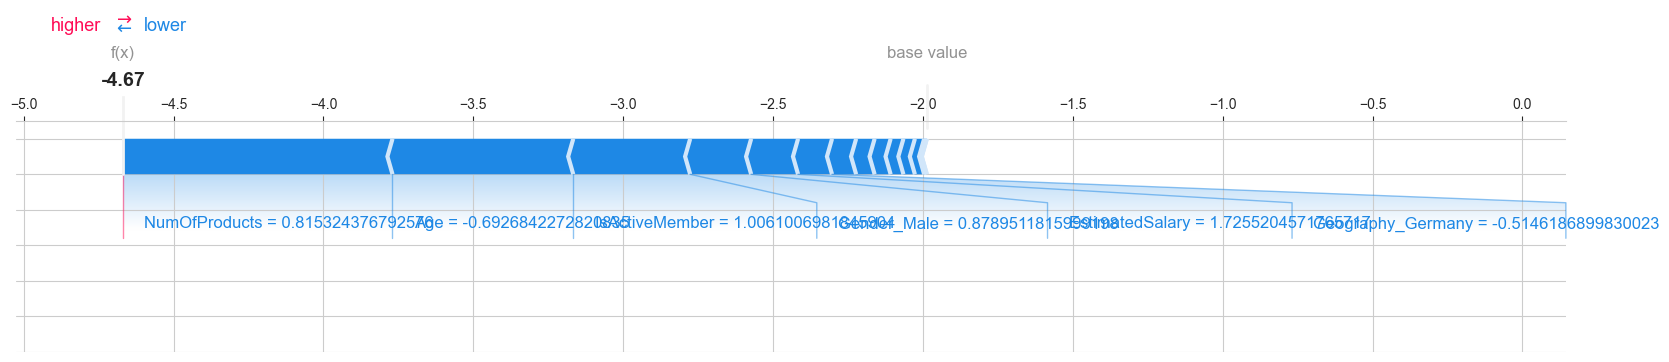

In [29]:
if HAS_SHAP:
    probas = gb_pipeline.predict_proba(X_test)[:, 1]

    high_risk_idx = int(np.argmax(probas))
    mid_risk_idx  = int(np.argsort(np.abs(probas - 0.5))[0])
    low_risk_idx  = int(np.argmin(probas))

    selected_indices = [high_risk_idx, mid_risk_idx, low_risk_idx]
    risk_labels  = ['Risque eleve', 'Risque moyen', 'Risque faible']
    fname_labels = ['risque_eleve', 'risque_moyen', 'risque_faible']

    for idx, label, fname_lbl in zip(selected_indices, risk_labels, fname_labels):
        print(label + ' — Index ' + str(idx) + ' — Proba churn : ' + str(round(float(probas[idx]), 3)))
        plt.figure(figsize=(12, 4))
        shap.force_plot(
            explainer.expected_value,
            shap_values[idx].values,
            X_test_transformed.iloc[idx],
            feature_names=X_test_transformed.columns.tolist(),
            matplotlib=True,
            show=False,
        )
        plt.savefig(IMAGES_DIR / ('shap_force_' + fname_lbl + '.png'), dpi=150, bbox_inches='tight')
        plt.show()

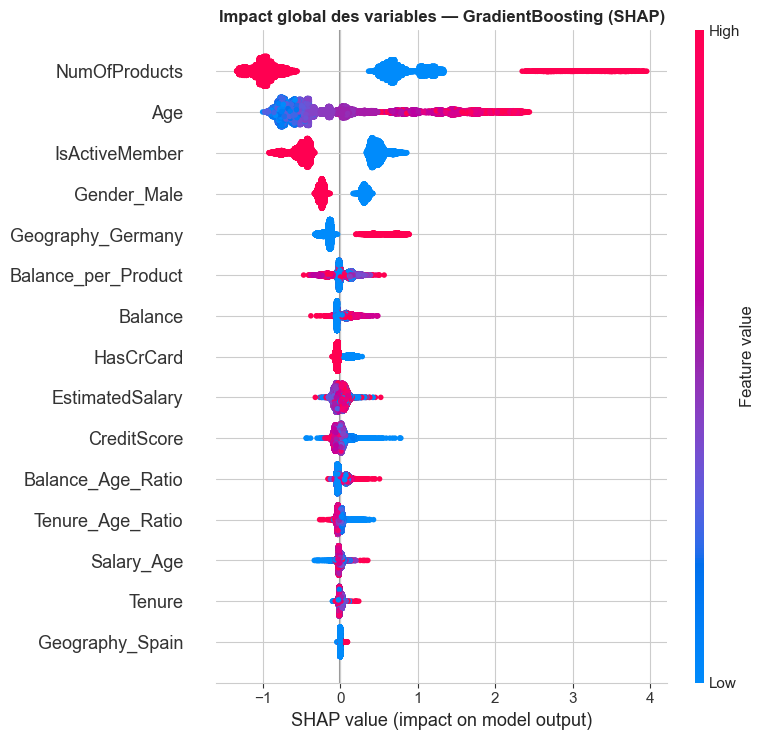

In [30]:
if HAS_SHAP:
    shap.plots.beeswarm(shap_values, max_display=15, show=False)
    plt.title('Impact global des variables — GradientBoosting (SHAP)', fontweight='bold')
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / 'shap_beeswarm.png', dpi=150, bbox_inches='tight')
    plt.show()

<a id="section-20"></a>
# Section 20 : Sauvegarde du meilleur modèle

Le pipeline final (`tuned_pipeline` ou `trained_models[best_model_name]`) est sérialisé en **trois formats** complémentaires :

| Format | Outil | Cas d'usage |
|---|---|---|
| **joblib** | `joblib.dump` | Recommandé pour les objets NumPy/sklearn : stockage efficace des grands tableaux via `mmap`. |
| **pickle** | `pickle.dump` | Sérialisation Python standard, compatible avec tous les environnements sans dépendance supplémentaire. |
| **dill** | `dill.dump` | Extension de pickle : supporte les lambdas, closures et fonctions locales (utile si le pipeline contient des scorers personnalisés). |

Les fichiers sont enregistrés dans `best_model/` à la racine du projet.

In [31]:
import pickle
import joblib
import dill

BEST_MODEL_DIR = PROJECT_ROOT / 'best_model'
BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_name_clean = best_model_name.lower().replace(' ', '_')

joblib_path = BEST_MODEL_DIR / f'{model_name_clean}_pipeline.joblib'
joblib.dump(eval_pipeline, joblib_path)
print(f'joblib  -> {joblib_path}')

pkl_path = BEST_MODEL_DIR / f'{model_name_clean}_pipeline.pkl'
with open(pkl_path, 'wb') as f:
    pickle.dump(eval_pipeline, f)
print(f'pickle  -> {pkl_path}')

dill_path = BEST_MODEL_DIR / f'{model_name_clean}_pipeline.dill'
with open(dill_path, 'wb') as f:
    dill.dump(eval_pipeline, f)
print(f'dill    -> {dill_path}')

print(f"\nModele '{best_model_name}' sauvegarde en 3 formats dans : {BEST_MODEL_DIR}")

joblib  -> C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\best_model\gradientboosting_pipeline.joblib
pickle  -> C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\best_model\gradientboosting_pipeline.pkl
dill    -> C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\best_model\gradientboosting_pipeline.dill

Modele 'GradientBoosting' sauvegarde en 3 formats dans : C:\Users\DELL\Desktop\ise2\Semestre2\Statistiques\Machine Learning 2\Projet_ML2\Projet_ML2_G8\best_model
